In [53]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.10.0+cu126
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [54]:
# Set relative paths to the datasets
relative_benign_path= "data\\processed\\Modbus Dataset\\benign\\ied1a\\MODBUS_ONLY_veth4edc015-normal-4.csv"
relative_external_attack_path = "data\\processed\\Modbus Dataset\\attack\\external\\ied1a\\MODBUS_ONLY_veth4edc015-0.csv"  # External attack file
relative_compromised_attack_path = "data\\processed\\Modbus Dataset\\attack\\compromised-scada\\ied1a\\MODBUS_ONLY_veth3614724-0.csv"  # Compromised attack file

# Convert relative paths to absolute paths
absolute_benign_path = (Path("../..") / relative_benign_path).resolve()
absolute_external_attack_path = (Path("../..") / relative_external_attack_path).resolve()
absolute_compromised_attack_path = (Path("../..") / relative_compromised_attack_path).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_benign_path)
print("Absolute path to external attack data:", absolute_external_attack_path)
print("Absolute path to compromised attack data:", absolute_compromised_attack_path)


Absolute path to clean data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\benign\ied1a\MODBUS_ONLY_veth4edc015-normal-4.csv
Absolute path to external attack data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\attack\external\ied1a\MODBUS_ONLY_veth4edc015-0.csv
Absolute path to compromised attack data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\attack\compromised-scada\ied1a\MODBUS_ONLY_veth3614724-0.csv


In [55]:
# Load the datasets
benign_data = pd.read_csv(absolute_benign_path)
external_attack_data = pd.read_csv(absolute_external_attack_path)
compromised_scada_attack_data = pd.read_csv(absolute_compromised_attack_path)

print(benign_data.columns.tolist())
print(f"Shape of benign data: {benign_data.shape}")
print(f"Shape of external attack data: {external_attack_data.shape}")
print(f"Shape of compromised SCADA attack data: {compromised_scada_attack_data.shape}")

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'tcp_stream', 'tcp_time_delta', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'request_frame', 'response_frame', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label']
Shape of benign data: (207079, 48)
Shape of external attack data: (137543, 48)
Shape of compromised SCADA attack data: (151443, 48)


In [56]:
benign_data_copy = benign_data.copy()
external_attack_data_copy = external_attack_data.copy()
compromised_scada_attack_data_copy = compromised_scada_attack_data.copy()

print("\nFirst few rows of benign data:")
display(benign_data.head())


First few rows of benign data:


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,tcp_stream,...,SYN,RST,PSH,ACK,URG,inter_arrival_time,time_from_start,requests_per_second,round_trip_time,label
0,283,1.674361e+09,2023-01-22T04:10:36.658912+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51182,502,12,140,...,0,0,1,1,0,NaN,0.000000,1,0.000844,NORMAL
1,285,1.674361e+09,2023-01-22T04:10:36.659756+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,51182,11,140,...,0,0,1,1,0,0.000844,0.000844,1,0.000844,NORMAL
2,292,1.674361e+09,2023-01-22T04:10:36.680828+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51184,502,12,142,...,0,0,1,1,0,0.021072,0.021916,2,0.000877,NORMAL
3,294,1.674361e+09,2023-01-22T04:10:36.681705+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,51184,10,142,...,0,0,1,1,0,0.000877,0.022793,2,0.000877,NORMAL
4,300,1.674361e+09,2023-01-22T04:10:36.702441+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,51186,502,12,143,...,0,0,1,1,0,0.020736,0.043529,3,0.000706,NORMAL



Correlations using Pearson method:
function_code          0.854000
requests_per_second    0.765569
time_from_start        0.698926
is_request             0.568289
modbus_length          0.534673
tcp_len                0.388441
pkt_len                0.388441
word_count             0.277876
bit_count              0.267288
tcp_seq                0.010161
FIN                    0.002823
tcp_time_delta        -0.012205
inter_arrival_time    -0.226111
tcp_ack               -0.567895
tcp_window_size       -0.568289
is_response           -0.568289
reference_num         -0.949213
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
byte_count                  NaN
exception_code              NaN
response_time               NaN
is_exception                NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK                         NaN
URG 

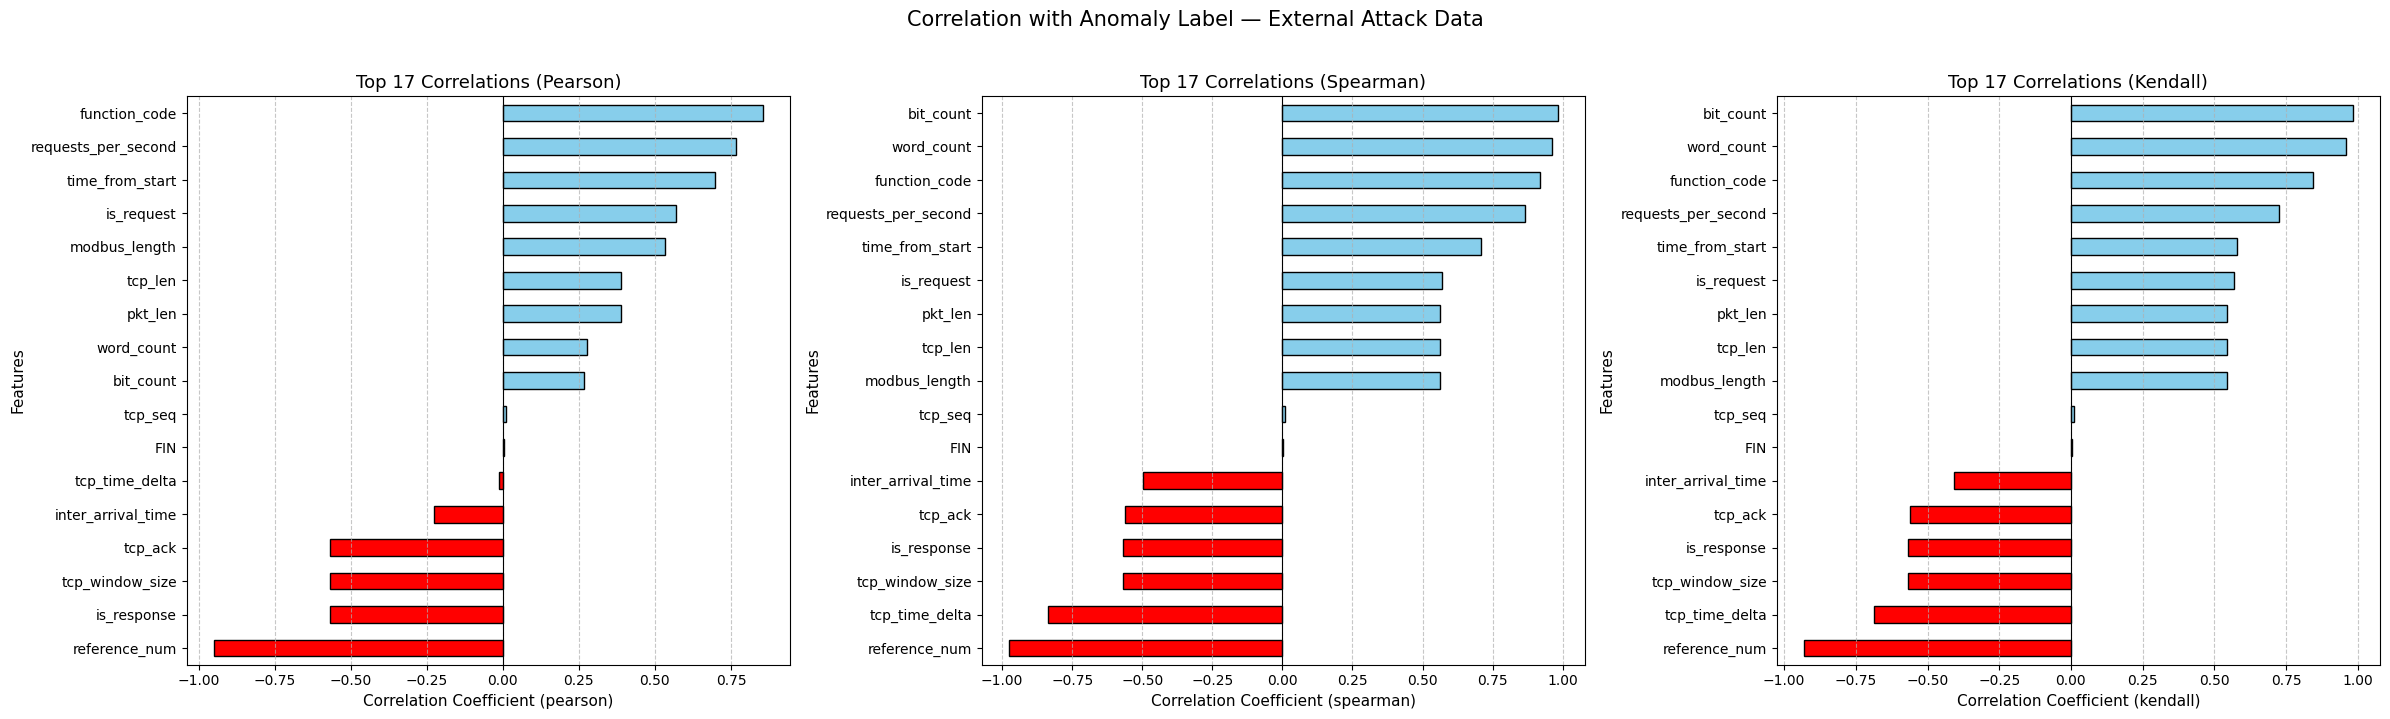

In [57]:
# Create numeric label FIRST (only if 'label' column exists)
if 'label' in benign_data.columns:
    benign_data['label_numeric'] = (benign_data['label'] == 'ANOMALY').astype(int)
if 'label' in external_attack_data.columns:
    external_attack_data['label_numeric'] = (external_attack_data['label'] == 'ANOMALY').astype(int)
if 'label' in compromised_scada_attack_data.columns:
    compromised_scada_attack_data['label_numeric'] = (compromised_scada_attack_data['label'] == 'ANOMALY').astype(int)

# Then drop columns
columns_to_drop = [
    'packet_number',
    'timestamp',
    'datetime',
    'src_ip',
    'dst_ip',
    'src_port',
    'dst_port',
    'tcp_stream',
    'transaction_id',
    'protocols',
    'unit_id',
    'tcp_flags',
    'function_name',
    'label',              # Drop original label after creating numeric version
    'request_frame',
    'response_frame',
]

benign_data = benign_data.drop(columns=columns_to_drop, errors='ignore')
external_attack_data = external_attack_data.drop(columns=columns_to_drop, errors='ignore')
compromised_scada_attack_data = compromised_scada_attack_data.drop(columns=columns_to_drop, errors='ignore')


# Compare all three
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, method in zip(axes, ['pearson', 'spearman', 'kendall']):
    target_variable = 'label_numeric'

    # Calculate correlations
    correlations = external_attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
    correlations.drop(target_variable, inplace=True)

    # Print the features and their correlation values for this method
    print(f"\nCorrelations using {method.capitalize()} method:")
    print(correlations)

    # Get top features by absolute value
    number_of_features = 17
    top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index
    top_correlations = correlations[top_feature_names].sort_values(ascending=True)

    colors = ['red' if x < 0 else 'skyblue' for x in top_correlations]
    top_correlations.plot(kind='barh', color=colors, edgecolor='black', ax=ax)  # <-- pass ax=ax
    ax.set_title(f'Top {number_of_features} Correlations ({method.capitalize()})', fontsize=13)
    ax.set_xlabel(f'Correlation Coefficient ({method})', fontsize=11)
    ax.set_ylabel('Features', fontsize=11)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.suptitle('Correlation with Anomaly Label — External Attack Data', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [58]:
# For the sake of simplicity, let's just print the top features for one method (e.g., Spearman)
method = 'spearman'  # You can change this to 'pearson' or 'kendall' as needed
target_variable = 'label_numeric'

# Calculate correlations
correlations = external_attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
correlations.drop(target_variable, inplace=True)  # Remove self-correlation

 # Get top features by absolute value
number_of_features = 5  #16
top_features = correlations.abs().sort_values(ascending=False).head(number_of_features).index
top_features = list(top_features)

# Print the top features and their correlation values
print(top_features)
print("-" * len(str(top_features)))

print(f"Top {number_of_features} features by absolute {method} correlation with label_numeric:")
for feature in top_features:
    corr_value = correlations[feature]
    print(f"{feature}: {corr_value:.4f}")

['bit_count', 'reference_num', 'word_count', 'function_code', 'requests_per_second']
------------------------------------------------------------------------------------
Top 5 features by absolute spearman correlation with label_numeric:
bit_count: 0.9820
reference_num: -0.9755
word_count: 0.9607
function_code: 0.9201
requests_per_second: 0.8642


In [59]:
def plot_features_over_time(df, features, x_col='packet_number', title='Features Over Time', ncols=2, color='blue'):
    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 3 * nrows))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        axes[i].plot(df[x_col], df[feature], linewidth=0.5, color=color)
        axes[i].set_title(f'{feature} by {x_col}', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=9)
        axes[i].set_xlabel(x_col, fontsize=9)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [60]:
print(top_features)

['bit_count', 'reference_num', 'word_count', 'function_code', 'requests_per_second']


In [61]:
# Add numeric_label columns to the copies (if 'label' column exists) so we can use them for coloring in the plots
if 'label' in benign_data_copy.columns:
    benign_data_copy['label_numeric'] = (benign_data_copy['label'] == 'ANOMALY').astype(int)
if 'label' in external_attack_data_copy.columns:
    external_attack_data_copy['label_numeric'] = (external_attack_data_copy['label'] == 'ANOMALY').astype(int)
if 'label' in compromised_scada_attack_data_copy.columns:
    compromised_scada_attack_data_copy['label_numeric'] = (compromised_scada_attack_data_copy['label'] == 'ANOMALY').astype(int)

# Ensure 'label_numeric' is included in the top features for plotting
if 'label_numeric' not in top_features: 
    top_features.append('label_numeric')  # Add label_numeric to the list of features to plot

In [62]:
print(top_features)

['bit_count', 'reference_num', 'word_count', 'function_code', 'requests_per_second', 'label_numeric']


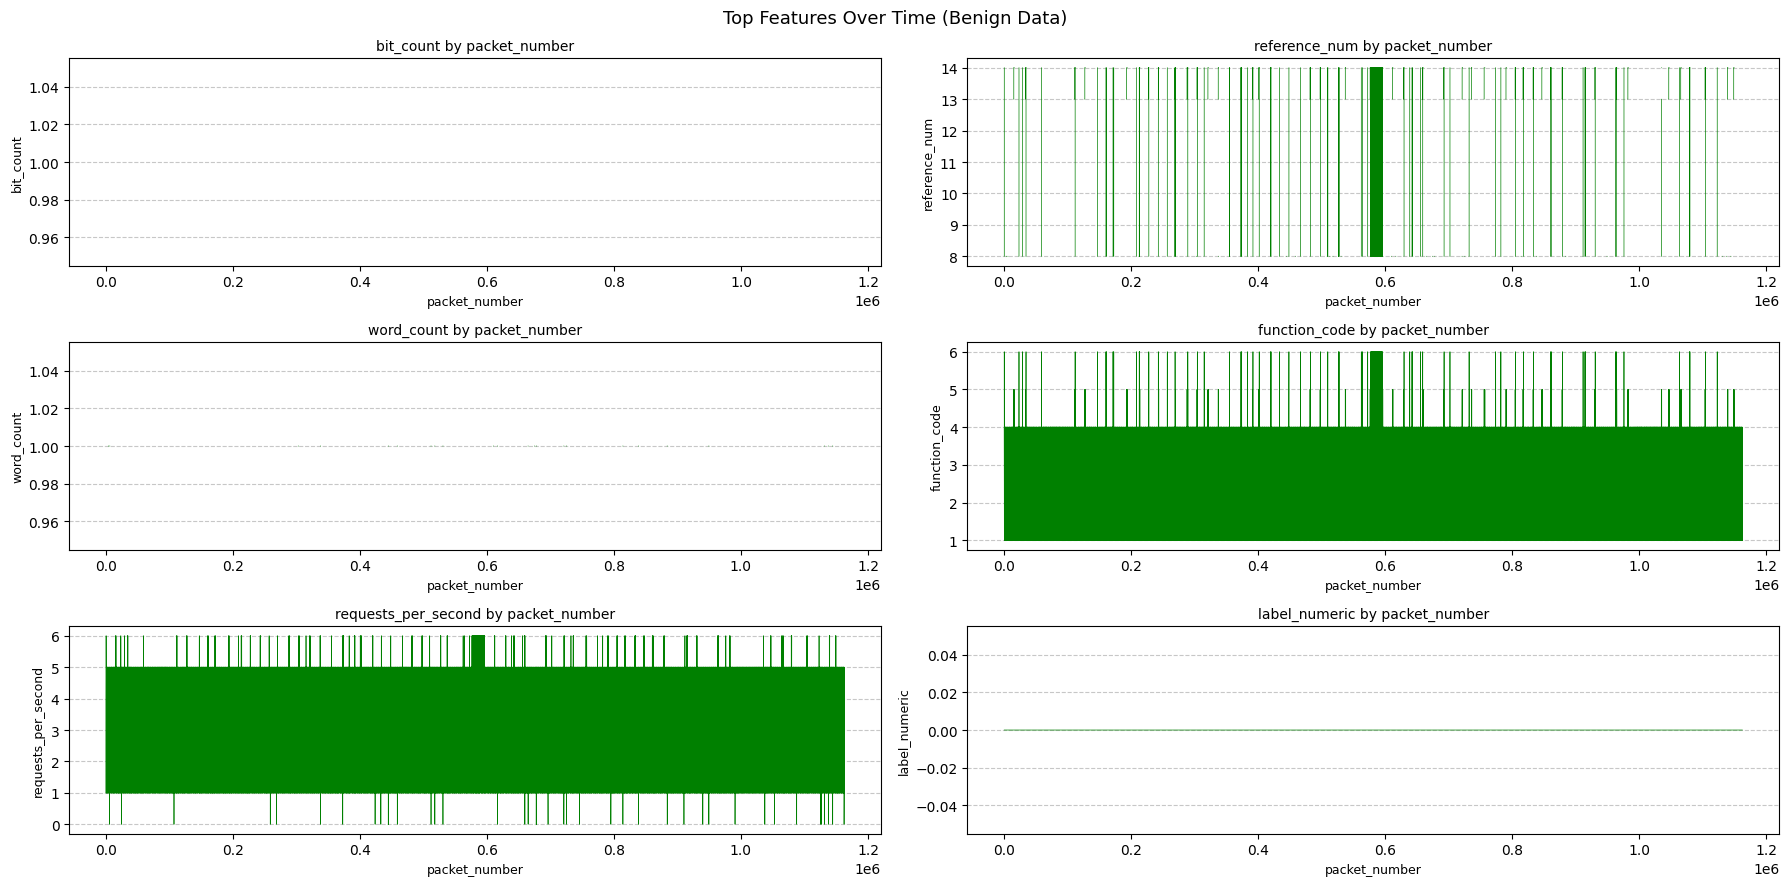

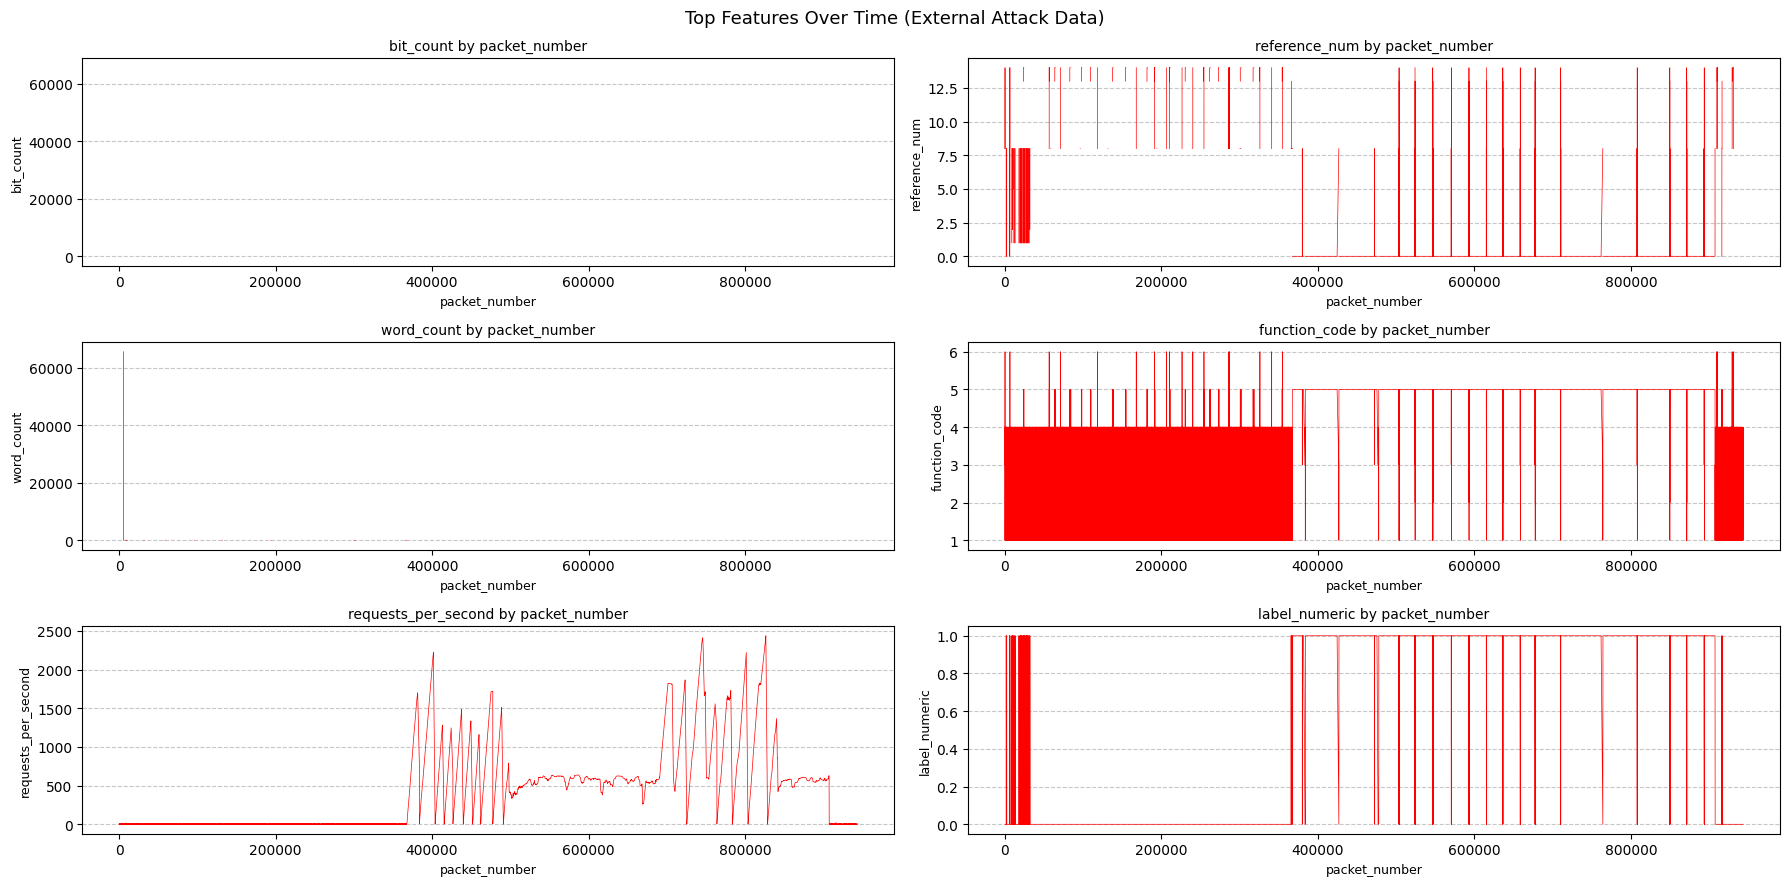

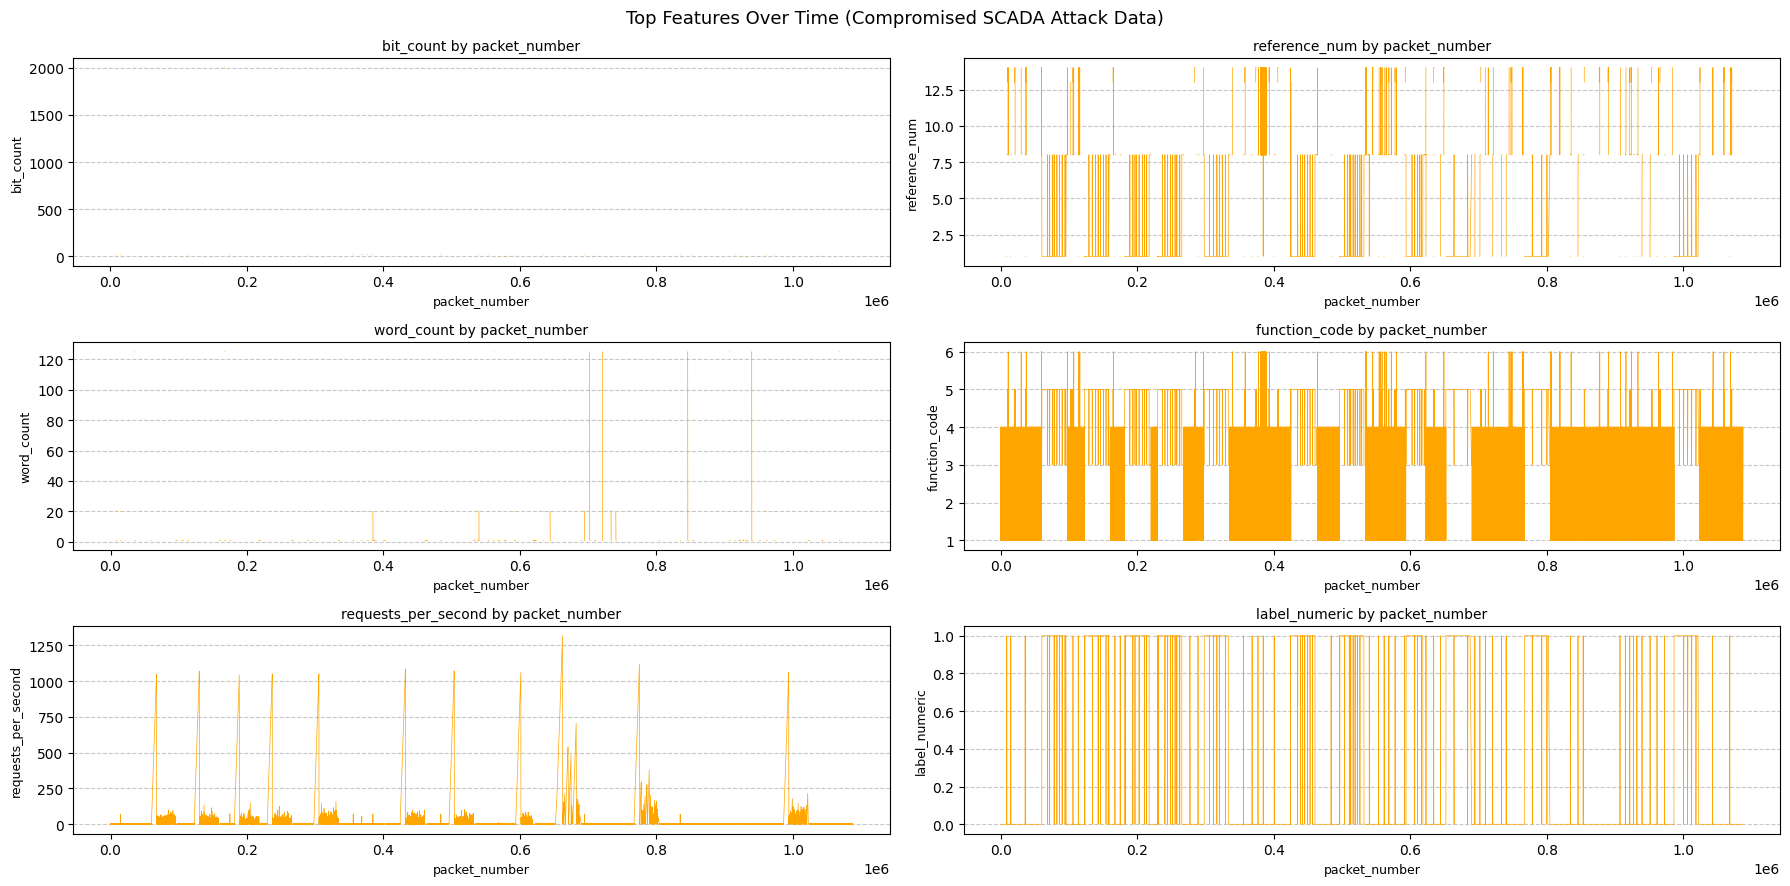

In [63]:
# Plot the top features over time for each dataset
plot_features_over_time(benign_data_copy, top_features, x_col='packet_number', title='Top Features Over Time (Benign Data)', color='green')
plot_features_over_time(external_attack_data_copy, top_features, x_col='packet_number', title='Top Features Over Time (External Attack Data)', color='red')
plot_features_over_time(compromised_scada_attack_data_copy, top_features, x_col='packet_number', title='Top Features Over Time (Compromised SCADA Attack Data)', color='orange')

# Define the LSTM Autoencoder

In [64]:
# Define the LSTM Autoencoder model
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        
        # Encoder
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Decoder
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=input_size,
            num_layers=num_layers,
            batch_first=True
        )
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        
        # Encode → compress to hidden representation
        _, (hidden, _) = self.encoder(x)          # hidden: (num_layers, batch, hidden_size)
        
        # Repeat hidden state across seq_len for decoder input
        latent = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)  # (batch, seq_len, hidden_size)
        
        # Decode → reconstruct input
        out, _ = self.decoder(latent)              # (batch, seq_len, input_size)
        
        return out

## Data Preparation for LSTM Autoencoder
Normalize features, create sliding-window sequences, and split into train/val sets.

In [65]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve

# --- Feature columns (top_features minus label_numeric) ---
feature_cols = [f for f in top_features if f != 'label_numeric']
print(f"Using features: {feature_cols}")
input_size = len(feature_cols)

# --- Fill NaN and normalize using ONLY benign statistics ---
scaler = MinMaxScaler()

benign_features = benign_data[feature_cols].fillna(0).values
benign_scaled = scaler.fit_transform(benign_features)  # fit on benign only

external_features = external_attack_data[feature_cols].fillna(0).values
external_scaled = scaler.transform(external_features)

compromised_features = compromised_scada_attack_data[feature_cols].fillna(0).values
compromised_scaled = scaler.transform(compromised_features)

print(f"Benign scaled shape: {benign_scaled.shape}")
print(f"External scaled shape: {external_scaled.shape}")
print(f"Compromised scaled shape: {compromised_scaled.shape}")

Using features: ['bit_count', 'reference_num', 'word_count', 'function_code', 'requests_per_second']
Benign scaled shape: (207079, 5)
External scaled shape: (137543, 5)
Compromised scaled shape: (151443, 5)


In [66]:
# --- Create sliding window sequences ---
def create_sequences(data, labels=None, seq_len=50):
    """Create overlapping sequences of length seq_len.
    If labels are provided, assign label=1 (anomaly) if ANY packet in the window is anomalous."""
    sequences = []
    seq_labels = []
    for i in range(len(data) - seq_len + 1):
        sequences.append(data[i : i + seq_len])
        if labels is not None:
            seq_labels.append(int(labels[i : i + seq_len].max()))  # 1 if any anomaly in window
    sequences = np.array(sequences)
    if labels is not None:
        return sequences, np.array(seq_labels)
    return sequences

seq_len = 50

# Benign sequences (all label=0 by definition)
benign_seqs = create_sequences(benign_scaled, seq_len=seq_len)
print(f"Benign sequences: {benign_seqs.shape}")

# Attack sequences with labels
ext_labels = external_attack_data['label_numeric'].values
external_seqs, external_seq_labels = create_sequences(external_scaled, ext_labels, seq_len=seq_len)
print(f"External attack sequences: {external_seqs.shape}, anomaly rate: {external_seq_labels.mean():.2%}")

comp_labels = compromised_scada_attack_data['label_numeric'].values
compromised_seqs, compromised_seq_labels = create_sequences(compromised_scaled, comp_labels, seq_len=seq_len)
print(f"Compromised sequences: {compromised_seqs.shape}, anomaly rate: {compromised_seq_labels.mean():.2%}")

Benign sequences: (207030, 50, 5)
External attack sequences: (137494, 50, 5), anomaly rate: 49.23%
Compromised sequences: (151394, 50, 5), anomaly rate: 31.49%


In [67]:
# --- Train / Validation split (benign only) ---
train_ratio = 0.8
n_train = int(len(benign_seqs) * train_ratio)

train_seqs = benign_seqs[:n_train]
val_seqs   = benign_seqs[n_train:]

# Convert to tensors
train_tensor = torch.FloatTensor(train_seqs)
val_tensor   = torch.FloatTensor(val_seqs)

print(f"Train: {train_tensor.shape}, Val: {val_tensor.shape}")

# DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_tensor), batch_size=batch_size, shuffle=False)

Train: torch.Size([165624, 50, 5]), Val: torch.Size([41406, 50, 5])


## Training the LSTM Autoencoder
Train on benign traffic only — the model learns to reconstruct normal patterns.

In [ ]:
# --- Hyperparameters ---
hidden_size = 64
num_layers  = 2
epochs = 50
lr = 1e-4  # ← lowered from 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LSTMAutoencoder(input_size, hidden_size, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)  # ← added

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← added
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)
            recon = model(batch)
            v_loss += criterion(recon, batch).item()
    val_losses.append(v_loss / len(val_loader))
    scheduler.step(val_losses[-1])  # ← added
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train: {train_losses[-1]:.6f} | Val: {val_losses[-1]:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

Using device: cuda
Epoch 10/100 | Train: 0.060525 | Val: 0.046756 | LR: 1.00e-04
Epoch 20/100 | Train: 0.032448 | Val: 0.031137 | LR: 1.00e-04
Epoch 30/100 | Train: 0.028973 | Val: 0.028838 | LR: 1.00e-04
Epoch 40/100 | Train: 0.026250 | Val: 0.025042 | LR: 1.00e-04
Epoch 50/100 | Train: 0.032716 | Val: 0.030152 | LR: 1.00e-04
Epoch 60/100 | Train: 0.024015 | Val: 0.023029 | LR: 1.00e-04
Epoch 70/100 | Train: 0.020225 | Val: 0.019015 | LR: 1.00e-04
Epoch 80/100 | Train: 0.017365 | Val: 0.016311 | LR: 1.00e-04
Epoch 90/100 | Train: 0.015764 | Val: 0.014864 | LR: 1.00e-04
Epoch 100/100 | Train: 0.015386 | Val: 0.013757 | LR: 1.00e-04


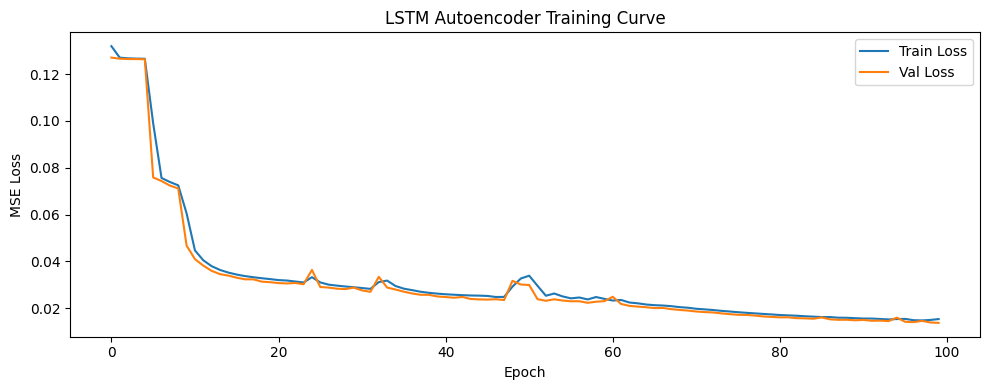

In [69]:
# --- Plot training curves ---
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Autoencoder Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Anomaly Threshold
Compute per-sequence reconstruction error on benign validation data and set threshold at the 95th or 99th percentile.

In [70]:
def compute_reconstruction_errors(model, data_tensor, device, batch_size=256):
    """Compute per-sequence MSE reconstruction error."""
    model.eval()
    errors = []
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            recon = model(batch)
            # Per-sequence MSE: mean over (seq_len, features)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2))  # (batch,)
            errors.append(mse.cpu().numpy())
    return np.concatenate(errors)

# Reconstruction errors on benign validation set
val_errors = compute_reconstruction_errors(model, val_tensor, device)

# Set thresholds
threshold_95 = np.percentile(val_errors, 95)
threshold_99 = np.percentile(val_errors, 99)
print(f"Benign val errors — mean: {val_errors.mean():.6f}, std: {val_errors.std():.6f}")
print(f"Threshold (95th pctl): {threshold_95:.6f}")
print(f"Threshold (99th pctl): {threshold_99:.6f}")

Benign val errors — mean: 0.013757, std: 0.005288
Threshold (95th pctl): 0.014440
Threshold (99th pctl): 0.030362


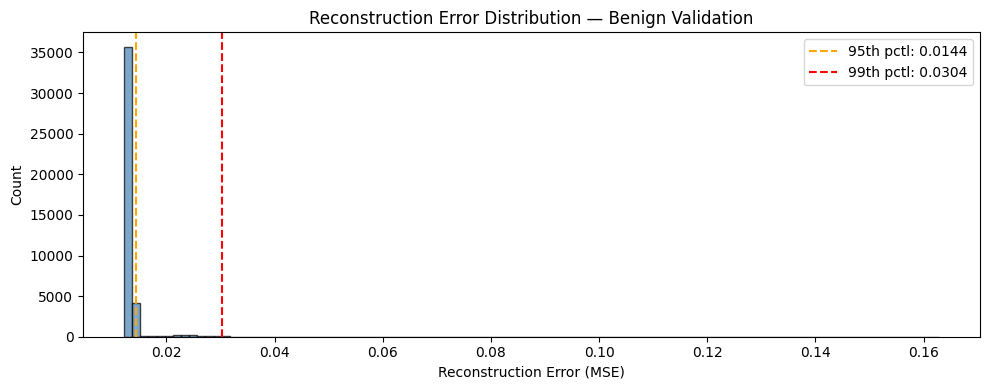

In [71]:
# --- Plot error distribution on benign data ---
plt.figure(figsize=(10, 4))
plt.hist(val_errors, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(threshold_95, color='orange', linestyle='--', label=f'95th pctl: {threshold_95:.4f}')
plt.axvline(threshold_99, color='red', linestyle='--', label=f'99th pctl: {threshold_99:.4f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.title('Reconstruction Error Distribution — Benign Validation')
plt.legend()
plt.tight_layout()
plt.show()

## Anomaly Detection on Attack Data
Apply the trained model to external and compromised-SCADA attack datasets.

In [72]:
# --- Compute errors on attack datasets ---
external_tensor = torch.FloatTensor(external_seqs)
compromised_tensor = torch.FloatTensor(compromised_seqs)

external_errors = compute_reconstruction_errors(model, external_tensor, device)
compromised_errors = compute_reconstruction_errors(model, compromised_tensor, device)

print(f"External attack errors — mean: {external_errors.mean():.6f}, std: {external_errors.std():.6f}")
print(f"Compromised attack errors — mean: {compromised_errors.mean():.6f}, std: {compromised_errors.std():.6f}")

External attack errors — mean: 27060.007812, std: 654661.625000
Compromised attack errors — mean: 282.240204, std: 1908.306396


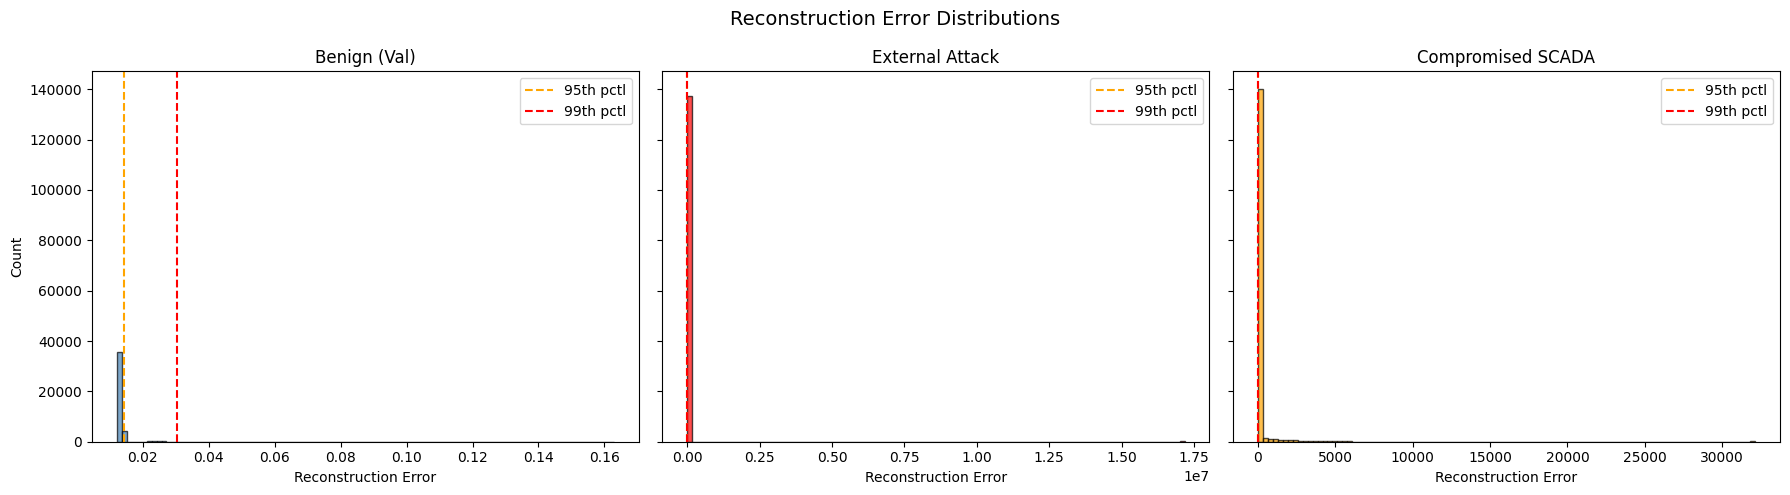

In [73]:
# --- Compare error distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, errors, title, color in zip(axes,
    [val_errors, external_errors, compromised_errors],
    ['Benign (Val)', 'External Attack', 'Compromised SCADA'],
    ['steelblue', 'red', 'orange']):
    ax.hist(errors, bins=100, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(threshold_95, color='orange', linestyle='--', label='95th pctl')
    ax.axvline(threshold_99, color='red', linestyle='--', label='99th pctl')
    ax.set_title(title)
    ax.set_xlabel('Reconstruction Error')
    ax.legend()

axes[0].set_ylabel('Count')
plt.suptitle('Reconstruction Error Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Evaluation
Classify sequences using the threshold and compute precision, recall, F1, and AUC-ROC.

In [74]:
def evaluate_detection(errors, true_labels, threshold, dataset_name):
    """Evaluate anomaly detection performance."""
    preds = (errors > threshold).astype(int)
    
    print(f"\n{'='*60}")
    print(f" {dataset_name} — Threshold: {threshold:.6f}")
    print(f"{'='*60}")
    print(f"Detected anomalies: {preds.sum()} / {len(preds)} ({preds.mean():.2%})")
    print(f"True anomalies:     {true_labels.sum()} / {len(true_labels)} ({true_labels.mean():.2%})")
    print()
    print(classification_report(true_labels, preds, target_names=['Normal', 'Anomaly'], zero_division=0))
    
    # AUC-ROC (using continuous errors, not binary preds)
    if len(np.unique(true_labels)) > 1:
        auc = roc_auc_score(true_labels, errors)
        print(f"AUC-ROC: {auc:.4f}")
    else:
        print("AUC-ROC: N/A (only one class present)")
    
    return preds

# Evaluate with 95th percentile threshold
print("\n" + "#"*60)
print("# Using 95th Percentile Threshold")
print("#"*60)
ext_preds_95 = evaluate_detection(external_errors, external_seq_labels, threshold_95, 'External Attack')
comp_preds_95 = evaluate_detection(compromised_errors, compromised_seq_labels, threshold_95, 'Compromised SCADA')

print("\n" + "#"*60)
print("# Using 99th Percentile Threshold")
print("#"*60)
ext_preds_99 = evaluate_detection(external_errors, external_seq_labels, threshold_99, 'External Attack')
comp_preds_99 = evaluate_detection(compromised_errors, compromised_seq_labels, threshold_99, 'Compromised SCADA')


############################################################
# Using 95th Percentile Threshold
############################################################

 External Attack — Threshold: 0.014440
Detected anomalies: 70808 / 137494 (51.50%)
True anomalies:     67693 / 137494 (49.23%)

              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     69801
     Anomaly       0.96      1.00      0.98     67693

    accuracy                           0.98    137494
   macro avg       0.98      0.98      0.98    137494
weighted avg       0.98      0.98      0.98    137494

AUC-ROC: 1.0000

 Compromised SCADA — Threshold: 0.014440
Detected anomalies: 59379 / 151394 (39.22%)
True anomalies:     47673 / 151394 (31.49%)

              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94    103721
     Anomaly       0.80      1.00      0.89     47673

    accuracy                           0.92    151394
   macro avg       0.9

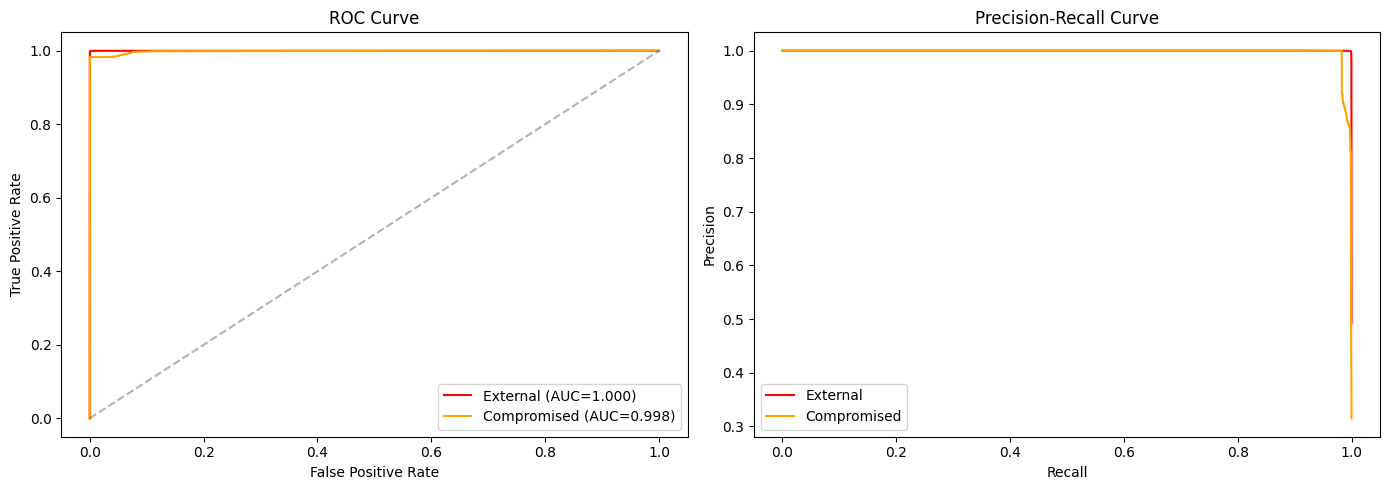

In [75]:
# --- ROC and Precision-Recall curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for errors, labels, name, color in [
    (external_errors, external_seq_labels, 'External', 'red'),
    (compromised_errors, compromised_seq_labels, 'Compromised', 'orange')
]:
    if len(np.unique(labels)) < 2:
        continue
    
    # ROC
    fpr, tpr, _ = roc_curve(labels, errors)
    auc = roc_auc_score(labels, errors)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
    
    # PR
    prec, rec, _ = precision_recall_curve(labels, errors)
    axes[1].plot(rec, prec, color=color, label=name)

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

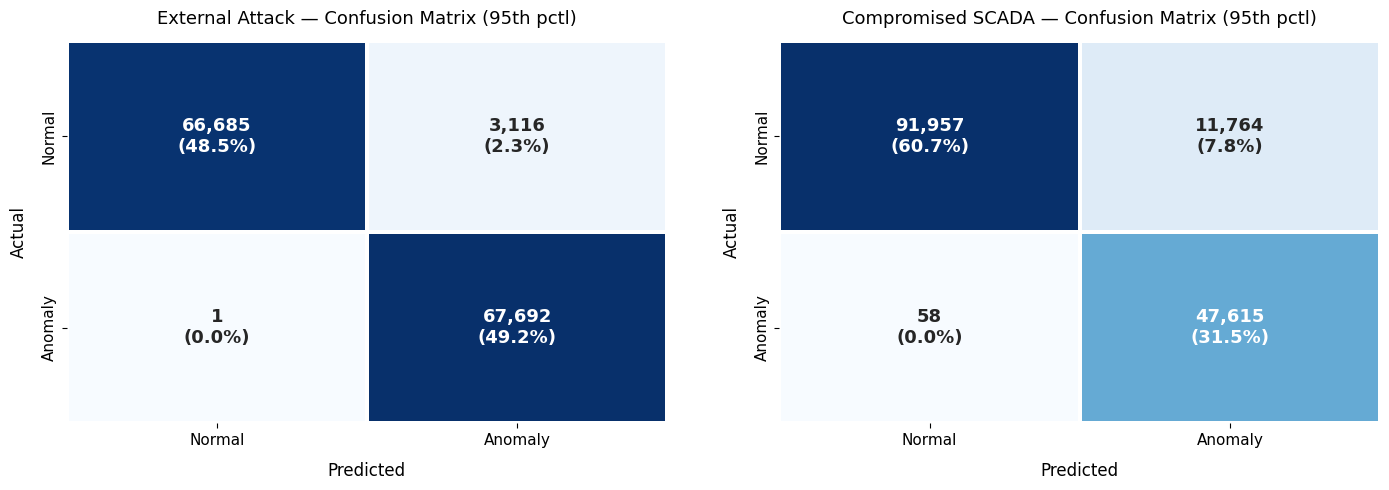

In [79]:
# --- Confusion Matrices (95th percentile threshold) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, labels, title in zip(
    axes,
    [ext_preds_95, comp_preds_95],
    [external_seq_labels, compromised_seq_labels],
    ['External Attack', 'Compromised SCADA'],
):
    cm = confusion_matrix(labels, preds)
    total = cm.sum()
    annot_labels = np.array([
        [f"{val:,}\n({val/total*100:.1f}%)" for val in row]
        for row in cm
    ])

    sns.heatmap(
        cm, annot=annot_labels, fmt='', cmap='Blues', ax=ax,
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'],
        annot_kws={'size': 13, 'weight': 'bold'},
        linewidths=1.5, linecolor='white',
        cbar=False,
    )
    ax.set_xlabel('Predicted', fontsize=12, labelpad=10)
    ax.set_ylabel('Actual', fontsize=12, labelpad=10)
    ax.set_title(f'{title} — Confusion Matrix (95th pctl)', fontsize=13, pad=12)
    ax.tick_params(labelsize=11)

plt.tight_layout(w_pad=4)
plt.show()

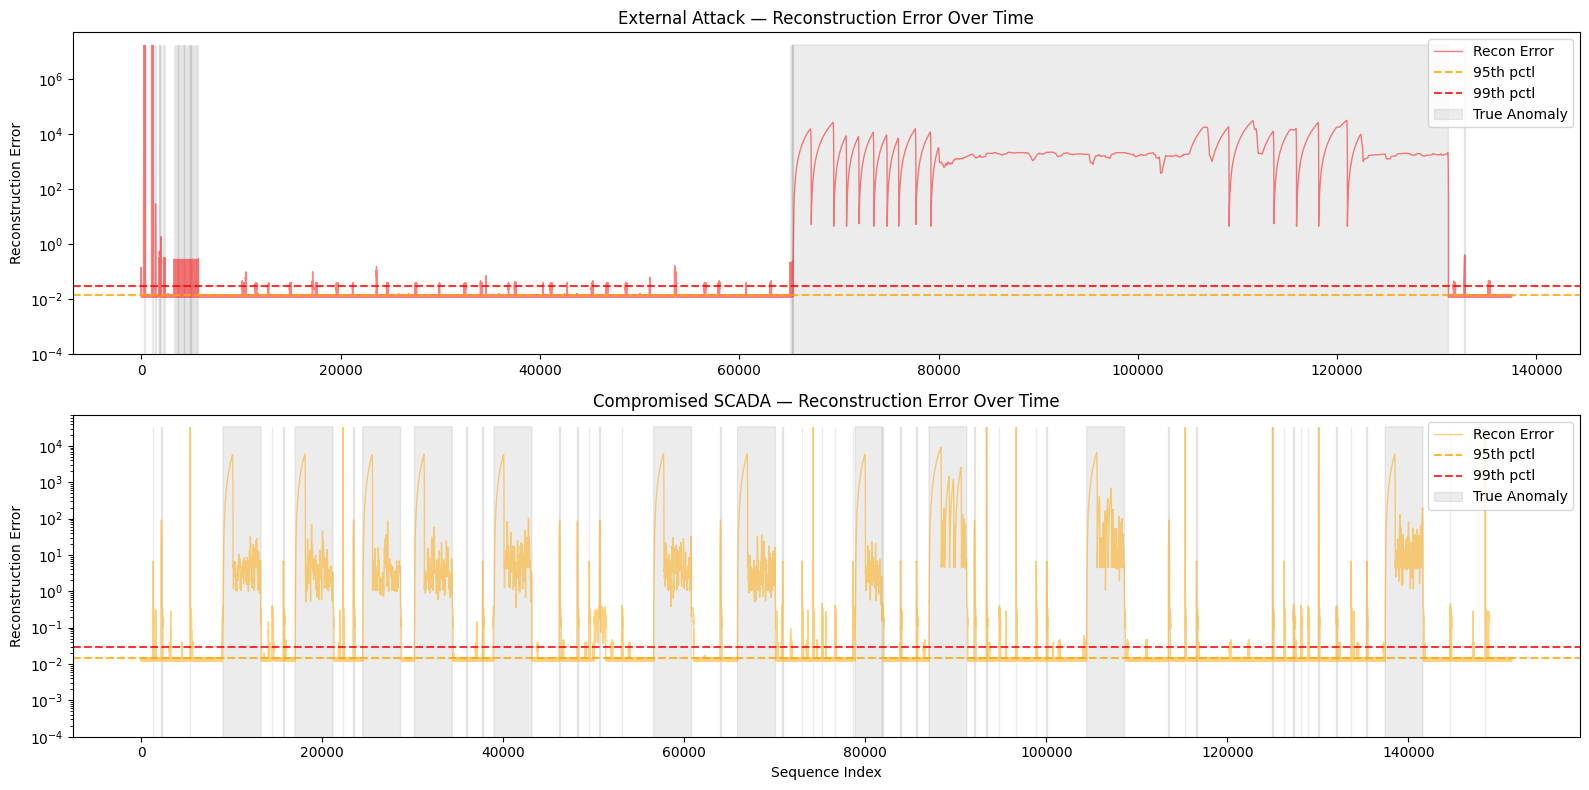

In [ ]:
# --- Reconstruction error over time (attack datasets) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, errors, labels, title, color in zip(axes,
    [external_errors, compromised_errors],
    [external_seq_labels, compromised_seq_labels],
    ['External Attack', 'Compromised SCADA'],
    ['red', 'orange']):
    
    ax.plot(errors, alpha=0.5, linewidth=1, color=color, label='Recon Error')
    ax.axhline(threshold_95, color='orange', linestyle='--', alpha=0.8, label='95th pctl')
    ax.axhline(threshold_99, color='red', linestyle='--', alpha=0.8, label='99th pctl')
    
    # Shade true anomaly regions
    anomaly_mask = labels.astype(bool)
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else errors.max()
    ax.fill_between(
        range(len(labels)), 0, y_top,
        where=anomaly_mask, alpha=0.15, color='gray', label='True Anomaly'
    )

    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-4)
    
    ax.set_ylabel('Reconstruction Error')
    ax.set_title(f'{title} — Reconstruction Error Over Time')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Sequence Index')
plt.tight_layout()
plt.show()

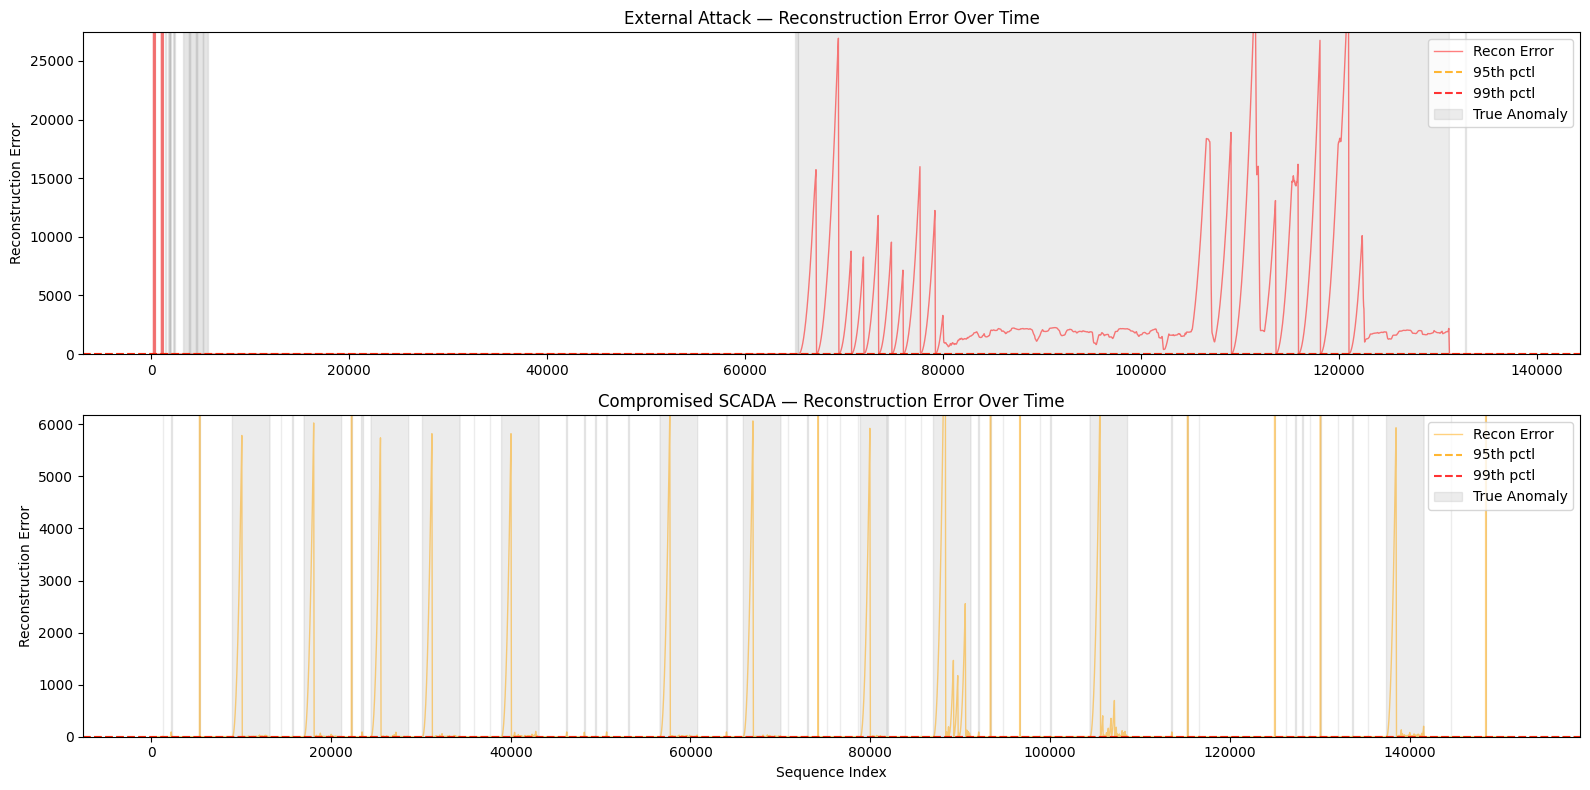

In [78]:
# --- Reconstruction error over time (attack datasets) with y-axis clipping ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, errors, labels, title, color in zip(axes,
    [external_errors, compromised_errors],
    [external_seq_labels, compromised_seq_labels],
    ['External Attack', 'Compromised SCADA'],
    ['red', 'orange']):
    
    # Clip y-axis to a reasonable range so threshold region is visible
    y_cap = np.percentile(errors, 99.5)
    
    ax.plot(errors, alpha=0.5, linewidth=1, color=color, label='Recon Error')
    ax.axhline(threshold_95, color='orange', linestyle='--', alpha=0.8, label='95th pctl')
    ax.axhline(threshold_99, color='red', linestyle='--', alpha=0.8, label='99th pctl')
    
    anomaly_mask = labels.astype(bool)
    ax.fill_between(range(len(labels)), 0, y_cap,
                    where=anomaly_mask, alpha=0.15, color='gray', label='True Anomaly')
    
    ax.set_ylim(0, y_cap)
    ax.set_ylabel('Reconstruction Error')
    ax.set_title(f'{title} — Reconstruction Error Over Time')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Sequence Index')
plt.tight_layout()
plt.show()